# Window Functions and Field Algebra

This notebook sits between `sfc_projection.ipynb` and the measurement notebooks. After a catalog has been converted into a `SFCField` object, PyHermes lets you manipulate two objects directly:

- `SFCField`: a multiresolution field, stored in `epsilon`.
- `WindowFunc`: a Fourier-space filter, stored as `w_kernel` after it is built.

The goal here is to show the arithmetic supported by both objects, then introduce ordinary smoothing windows. These are not 2PCF `pair_window` definitions; pair windows are discussed in `corr2pcf.ipynb`.

In [1]:
from pathlib import Path
import copy
import os

import numpy as np
from numba import njit

from pyhermes.io import SFCField, WindowFunc
from pyhermes.utils.window_functions import (
    window_function_cylshell_numba,
    window_function_disk_numba,
    window_function_sphere_numba,
)

cwd = Path.cwd().resolve()
if cwd.name == "notebooks":
    os.chdir(cwd.parent)
elif (cwd / "examples").is_dir():
    os.chdir(cwd / "examples")

print(f"Working directory: {Path.cwd()}")

Working directory: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples


## 1. Load Example Fields

`sfc_projection.ipynb` builds the files used below. Here `D` and `R` retain their raw total weights. To reproduce correlation-estimator algebra, we convert them to unit-total-weight fields; the scalar `rho = 1 / V` is the matching uniform-random shortcut.

In [2]:
D = SFCField(data_path="./output/quijote8000_snap004_sfc.pkl", threads=8)
R = SFCField(data_path="./output/random_sfc.pkl", threads=8)

D_stat = D
R_stat = R
rho = 1.0 / D_stat.V
print(f"D.epsilon shape = {D.epsilon.shape}")
print(f"uniform density rho = {rho:.6e}")

16:48:51 - INFO - pyhermes.io.base:SFCField - Reading SFCField data from ---> ./output/quijote8000_snap004_sfc.pkl <---
16:48:51 - INFO - pyhermes.io.base:SFCField - epsilon: Shape(256, 256, 256), Min = -3.215e-06, Max = 1.343e-05, Mean = 5.96e-08, Sum = 1
16:48:51 - INFO - pyhermes.io.base:SFCField - Reading SFCField data from ---> ./output/random_sfc.pkl <---
16:48:52 - INFO - pyhermes.io.base:SFCField - epsilon: Shape(256, 256, 256), Min = -2.192e-07, Max = 9.48e-07, Mean = 5.96e-08, Sum = 1
D.epsilon shape = (256, 256, 256)
uniform density rho = 5.960464e-08


## 2. `SFCField` Arithmetic

`SFCField` arithmetic acts on `epsilon` and returns a new `SFCField` object. This is useful for building density contrasts or simple derived fields before applying a window.

In [3]:
delta_from_random = D_stat - R_stat
delta_from_uniform = D_stat - rho
mean_field = (D + R) / 2.0
scaled_delta = 2.0 * delta_from_uniform
field_product = D * R

print(delta_from_random.epsilon.shape)
print(mean_field.epsilon.shape)
print(scaled_delta.epsilon.shape)
print(field_product.epsilon.shape)

(256, 256, 256)
(256, 256, 256)
(256, 256, 256)
(256, 256, 256)


Supported field operations are:

```python
D1 + D2
D1 - D2
D1 * D2
D + a
D - a
a - D
a * D
D * a
D / a
```

Here `a` is a scalar. Division is only defined as `D / a`; `a / D` and `D1 / D2` are intentionally left out because their numerical and physical meaning is less clean.

## 3. Basic Smoothing with `WindowFunc`

A `WindowFunc` is built from a small dictionary and the `sfc_info` of the field it will filter. The actual kernel is built lazily when the window is used by `D @ W` or when `W.as_array()` is called.

In [4]:
def make_window(params, base=D):
    return WindowFunc(copy.deepcopy(params), base.sfc_info, threads=8)

W_sphere20 = make_window({"type": "sphere", "len_args": {"R": 20.0}})
D_sphere20 = D @ W_sphere20
delta_sphere20 = delta_from_uniform @ W_sphere20

print(D_sphere20.epsilon.shape)
print(delta_sphere20.epsilon.shape)

(256, 256, 256)
(256, 256, 256)


## 4. `WindowFunc` Arithmetic

`WindowFunc` arithmetic acts on `w_kernel`. A composite window is materialized: it stores the combined kernel directly instead of trying to reconstruct a new Numba function.

In [5]:
W_gauss8 = make_window({"type": "gaussian", "len_args": {"R": 8.0}})
W_mix = 0.7 * W_sphere20 + 0.3 * W_gauss8
D_mix = D @ W_mix

print(W_mix.type)
print(W_mix.as_array().shape)
print(D_mix.epsilon.shape)

composite
(256, 256, 129)
(256, 256, 256)


Supported window operations are:

```python
W1 + W2
W1 - W2
a * W
W * a
W / a
-W
```

Both windows in `W1 + W2` or `W1 - W2` must be built for the same grid: the same `J`, `box_size`, `phi_resolution`, `wavelet_mode`, `wavelet_level`, `bandwidth`, and kernel shape.

## 5. Built-In Ordinary Windows

The dictionaries below are ordinary smoothing/filter windows. They can be used as `window`, `window1`, `window2`, or a direct `WindowFunc` input. They are not yet 2PCF `pair_window` settings.

In [6]:
builtin_window_params = {
    "sphere": {
        "type": "sphere",
        "len_args": {"R": 20.0},
    },
    "gaussian": {
        "type": "gaussian",
        "len_args": {"R": 8.0},
    },
    "shell": {
        "type": "shell",
        "len_args": {"R": 20.0},
    },
    "cubic": {
        "type": "cubic",
        "len_args": {"Lx": 20.0, "Ly": 20.0, "Lz": 20.0},
    },
    "ring": {
        "type": "ring",
        "len_args": {"R": 20.0, "H": 10.0},
        "los_args": [0.0, 0.0, 1.0],
    },
    "disk": {
        "type": "disk",
        "len_args": {"R": 20.0, "H": 10.0},
        "los_args": [0.0, 0.0, 1.0],
    },
    "cylshell": {
        "type": "cylshell",
        "len_args": {"R": 20.0, "H": 10.0},
        "los_args": [0.0, 0.0, 1.0],
    },
    "cylinder": {
        "type": "cylinder",
        "len_args": {"R": 20.0, "H": 10.0},
        "los_args": [0.0, 0.0, 1.0],
    },
}

for name, params in builtin_window_params.items():
    print(f"{name:9s}: {params}")

sphere   : {'type': 'sphere', 'len_args': {'R': 20.0}}
gaussian : {'type': 'gaussian', 'len_args': {'R': 8.0}}
shell    : {'type': 'shell', 'len_args': {'R': 20.0}}
cubic    : {'type': 'cubic', 'len_args': {'Lx': 20.0, 'Ly': 20.0, 'Lz': 20.0}}
ring     : {'type': 'ring', 'len_args': {'R': 20.0, 'H': 10.0}, 'los_args': [0.0, 0.0, 1.0]}
disk     : {'type': 'disk', 'len_args': {'R': 20.0, 'H': 10.0}, 'los_args': [0.0, 0.0, 1.0]}
cylshell : {'type': 'cylshell', 'len_args': {'R': 20.0, 'H': 10.0}, 'los_args': [0.0, 0.0, 1.0]}
cylinder : {'type': 'cylinder', 'len_args': {'R': 20.0, 'H': 10.0}, 'los_args': [0.0, 0.0, 1.0]}


In [7]:
W_cubic20 = make_window(builtin_window_params["cubic"])
D_cubic20 = D @ W_cubic20
print(D_cubic20.epsilon.shape)

(256, 256, 256)


The line-of-sight windows (`ring`, `disk`, `cylshell`, `cylinder`) use `los_args`. Here `H` is a distance along the line of sight; for `cylshell` and `cylinder`, `H` is the half-height of the finite cylinder.

## 6. A Minimal Custom Window

A custom window is a Numba function for the Fourier-space kernel. The first three arguments must be `ki`, `kj`, and `kk`. Length parameters go in `len_args`; dimensionless controls go in `other_args`; line-of-sight components go in `los_args`.

In [8]:
@njit
def window_function_cos_shell_numba(ki, kj, kk, R, amplitude=1.0):
    k = np.sqrt(ki * ki + kj * kj + kk * kk)
    q = 2.0 * np.pi * k * R
    return amplitude * np.cos(q)

cos_shell_params = {
    "type": "cos_shell",
    "func": window_function_cos_shell_numba,
    "len_args": {"R": 20.0},
    "other_args": {"amplitude": 1.0},
    "kernel_mode": "octant",
}

W_cos_shell = make_window(cos_shell_params)
D_cos_shell = D @ W_cos_shell
print(D_cos_shell.epsilon.shape)

(256, 256, 256)


`kernel_mode="octant"` is fast and works when the kernel is invariant under independent sign flips of `kx`, `ky`, and `kz`. For a general custom window, use `kernel_mode="full_rfft"`; for line-of-sight windows you can often use `kernel_mode="auto"`.

## 7. Compose Windows from Built-In Pieces

Composite windows are often easier to build from existing windows than to write from scratch. The next examples show both routes and verify that the kernels agree.

### 7.1 Finite-Thickness Spherical Shell

A finite shell between `R_in` and `R_out` is a volume-weighted difference of two spherical top-hats:

```python
W = (R_out**3 * W_sphere(R_out) - R_in**3 * W_sphere(R_in)) / (R_out**3 - R_in**3)
```

In [9]:
@njit
def window_function_thick_shell_numba(ki, kj, kk, R_in, R_out):
    V_in = R_in**3
    V_out = R_out**3
    denom = V_out - V_in
    if denom == 0.0:
        k = np.sqrt(ki**2 + kj**2 + kk**2)
        q_out = 2.0 * np.pi * k * R_out
        if q_out == 0.0:
            return 1.0
        return np.sin(q_out) / q_out

    W_in = window_function_sphere_numba(ki, kj, kk, R_in)
    W_out = window_function_sphere_numba(ki, kj, kk, R_out)
    return (W_out * V_out - W_in * V_in) / denom

In [10]:
R_in, R_out = 10.0, 20.0
W_inner = make_window({"type": "sphere", "len_args": {"R": R_in}})
W_outer = make_window({"type": "sphere", "len_args": {"R": R_out}})

W_thick_from_builtin = (W_outer * R_out**3 - W_inner * R_in**3) / (R_out**3 - R_in**3)

W_thick_custom = make_window({
    "type": "thick_shell",
    "func": window_function_thick_shell_numba,
    "len_args": {"R_in": R_in, "R_out": R_out},
    "kernel_mode": "octant",
})

np.allclose(W_thick_custom.as_array(), W_thick_from_builtin.as_array())

True

### 7.2 Cylindrical Surface

A cylindrical surface can be composed from the side surface (`cylshell`) and the two caps (`disk`). The weights are proportional to their areas, giving

```python
W = (2H * W_cylshell + R * W_disk) / (2H + R)
```

In [11]:
@njit
def window_function_cylsurf_numba(ki, kj, kk, R, H, nx=0.0, ny=0.0, nz=1.0):
    denom = 2.0 * H + R
    if denom == 0.0:
        return 1.0
    win_cylshell = window_function_cylshell_numba(ki, kj, kk, R, H, nx, ny, nz)
    win_disk = window_function_disk_numba(ki, kj, kk, R, H, nx, ny, nz)
    return (2.0 * H * win_cylshell + R * win_disk) / denom

In [12]:
R_cyl, H_cyl = 10.0, 20.0
los_z = [0.0, 0.0, 1.0]

W_cylshell = make_window({
    "type": "cylshell",
    "len_args": {"R": R_cyl, "H": H_cyl},
    "los_args": los_z,
})
W_disk = make_window({
    "type": "disk",
    "len_args": {"R": R_cyl, "H": H_cyl},
    "los_args": los_z,
})

W_cylsurf_from_builtin = (2.0 * H_cyl * W_cylshell + R_cyl * W_disk) / (2.0 * H_cyl + R_cyl)

W_cylsurf_custom = make_window({
    "type": "cylsurf",
    "func": window_function_cylsurf_numba,
    "len_args": {"R": R_cyl, "H": H_cyl},
    "los_args": los_z,
    "kernel_mode": "auto",
})

np.allclose(W_cylsurf_custom.as_array(), W_cylsurf_from_builtin.as_array())

True

## 8. Smoothing Windows versus Pair Windows

Everything above treats `WindowFunc` as an ordinary smoothing/filter window: it acts on a field through `D @ W`. PyHermes also uses window functions as 2PCF `pair_window` definitions, where the window selects a separation bin instead of smoothing a field. That role is central to `Corr_2PCF` and is introduced in `corr2pcf.ipynb`.

## Appendix. Fourier-Space Sketches of Built-In Windows

This appendix generates one standalone Fourier-space sketch for each built-in PyHermes window. All curves are evaluated from `pyhermes.utils.window_functions.WINDOW_TYPE_DICT`.


Saved figure for sphere to figs/window_kspace_sphere.png


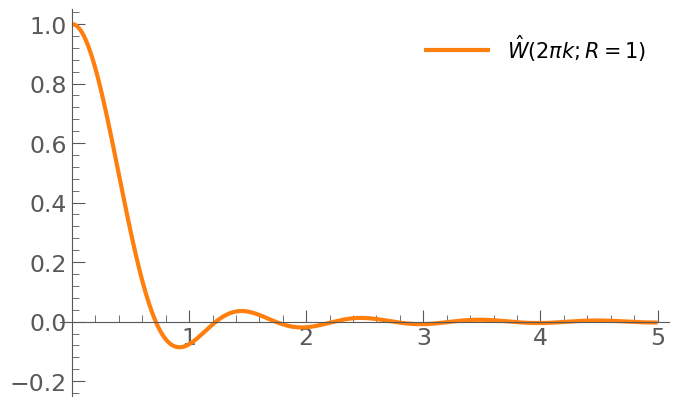

Saved figure for gaussian to figs/window_kspace_gaussian.png


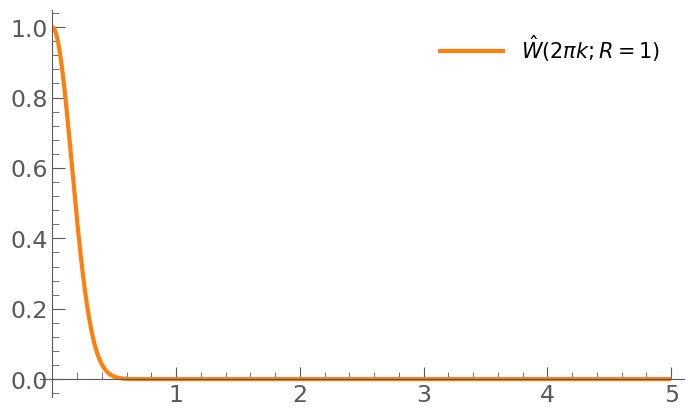

Saved figure for shell to figs/window_kspace_shell.png


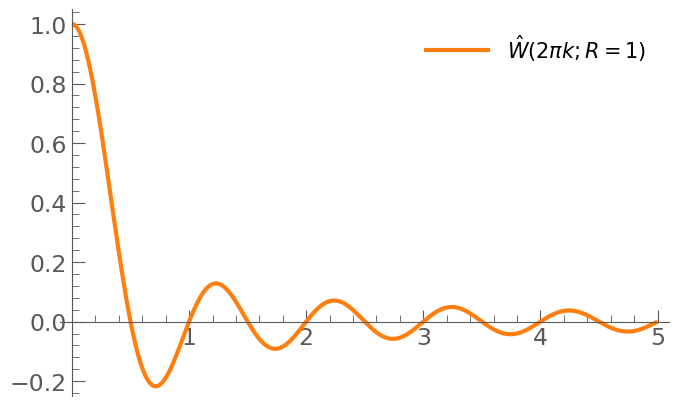

Saved figure for gaussian_shell to figs/window_kspace_gaussian_shell.png


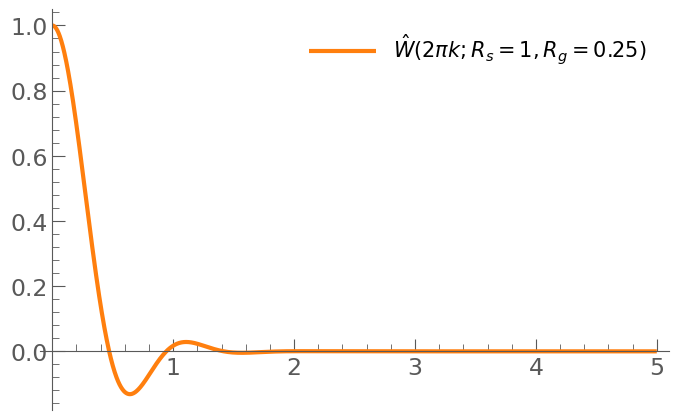

Saved figure for cubic to figs/window_kspace_cubic.png


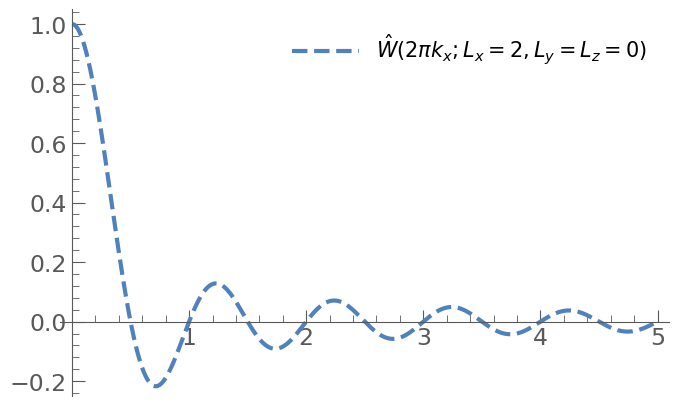

Saved figure for ring to figs/window_kspace_ring.png


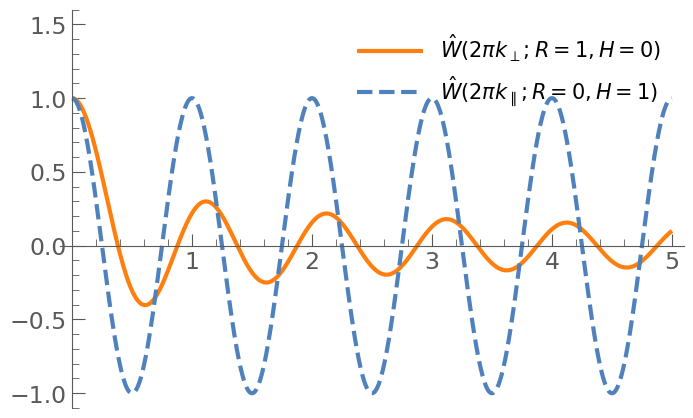

Saved figure for disk to figs/window_kspace_disk.png


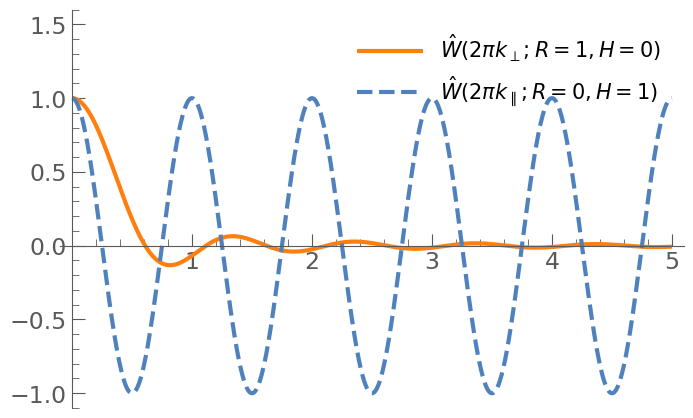

Saved figure for cylshell to figs/window_kspace_cylshell.png


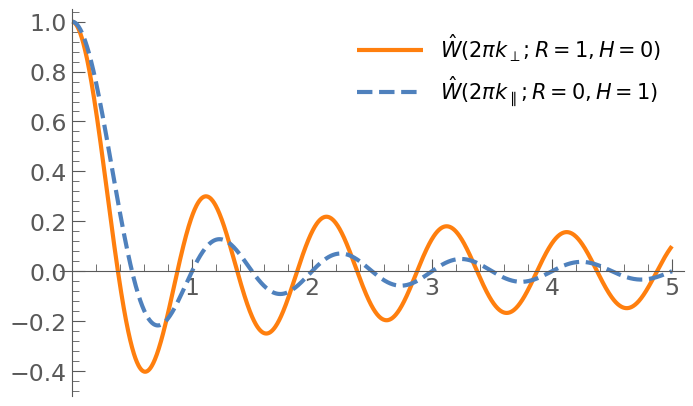

Saved figure for cylinder to figs/window_kspace_cylinder.png


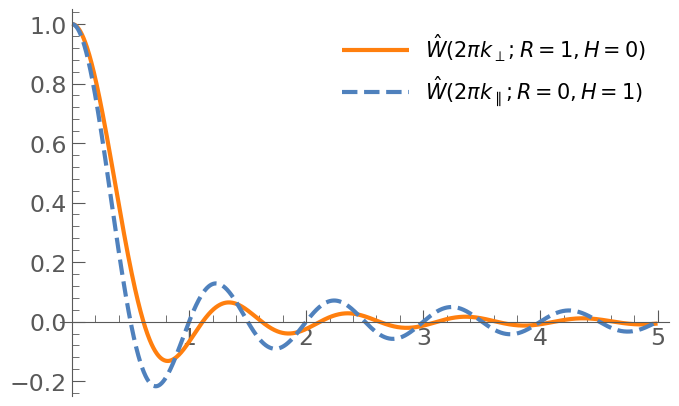

Saved figure for cw to figs/window_kspace_cw.png


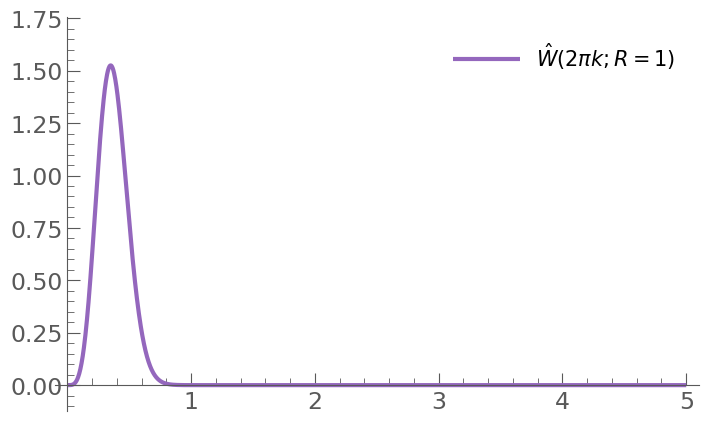

Saved figure for cws to figs/window_kspace_cws.png


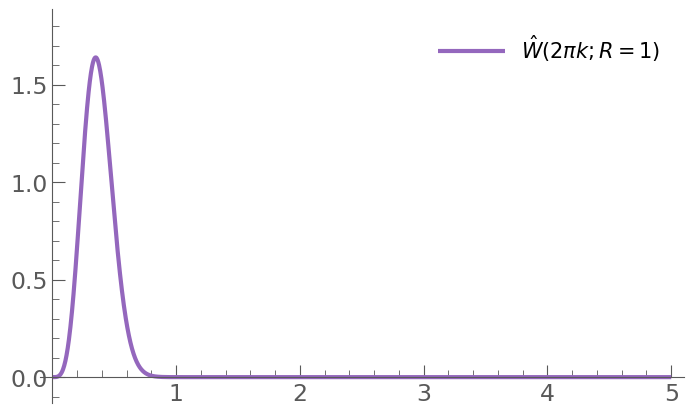

Saved figure for gdw to figs/window_kspace_gdw.png


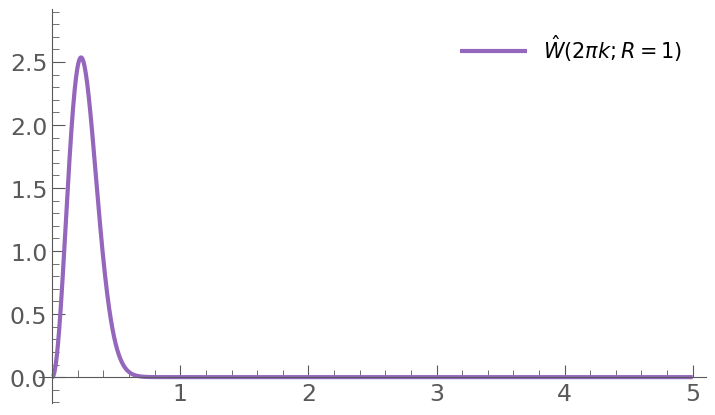

Saved figure for directional_derivative to figs/window_kspace_directional_derivative.png


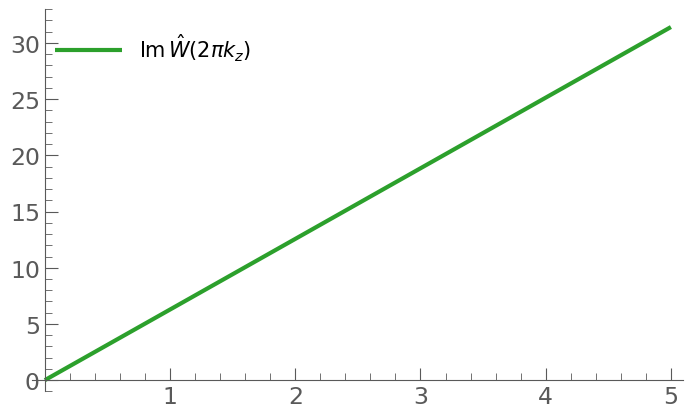

Saved figure for laplacian to figs/window_kspace_laplacian.png


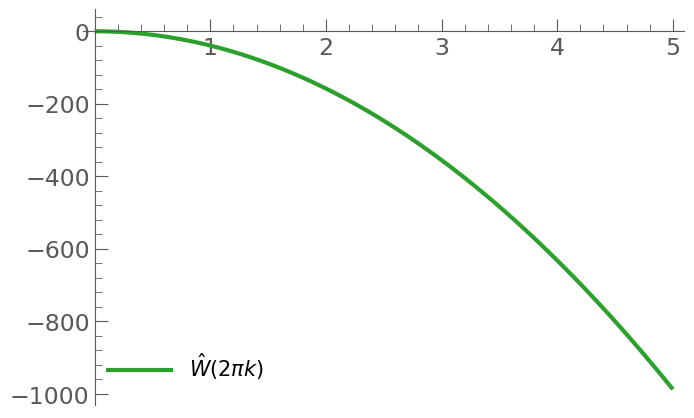

In [13]:
from pyhermes.utils.window_functions import WINDOW_TYPE_DICT
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

fig_dir = Path("figs")
fig_dir.mkdir(parents=True, exist_ok=True)

k = np.linspace(0.0, 5.0, 1600) 
zero = np.zeros_like(k)
radial_cut = (k, zero, zero)
parallel_cut = (zero, zero, k)

R_wavelet = 1.0
los_z = (0.0, 0.0, 1.0)
perp_args = (1.0, 0.0, *los_z)
parallel_args = (0.0, 1.0, *los_z)

window_plot_specs = [
    {
        "name": "sphere",
        "curves": [
            {"label": r"$\hat W(2\pi k; R=1)$", "cut": radial_cut, "args": (1.0,), "color": "#ff7f0e", "ls": "-"},
        ],
        "ylim": (-0.25, 1.05),
    },
    {
        "name": "gaussian",
        "curves": [
            {"label": r"$\hat W(2\pi k; R=1)$", "cut": radial_cut, "args": (1.0,), "color": "#ff7f0e", "ls": "-"},
        ],
        "ylim": (-0.05, 1.05),
    },
    {
        "name": "shell",
        "curves": [
            {"label": r"$\hat W(2\pi k; R=1)$", "cut": radial_cut, "args": (1.0,), "color": "#ff7f0e", "ls": "-"},
        ],
        "ylim": (-0.25, 1.05),
    },
    {
        "name": "gaussian_shell",
        "curves": [
            {"label": r"$\hat W(2\pi k; R_s=1,R_g=0.25)$", "cut": radial_cut, "args": (1.0, 0.25), "color": "#ff7f0e", "ls": "-"},
        ],
        "ylim": (-0.18, 1.05),
    },
    {
        "name": "cubic",
        "curves": [
            {"label": r"$\hat W(2\pi k_x; L_x=2,L_y=L_z=0)$", "cut": radial_cut, "args": (2.0, 0.0, 0.0), "color": "#4f81bd", "ls": "--"},
        ],
        "ylim": (-0.25, 1.05),
    },
    {
        "name": "ring",
        "curves": [
            {"label": r"$\hat W(2\pi k_{\perp}; R=1,H=0)$", "cut": radial_cut, "args": perp_args, "color": "#ff7f0e", "ls": "-"},
            {"label": r"$\hat W(2\pi k_{\parallel}; R=0,H=1)$", "cut": parallel_cut, "args": parallel_args, "color": "#4f81bd", "ls": "--"},
        ],
        "ylim": (-1.1, 1.6),
    },
    {
        "name": "disk",
        "curves": [
            {"label": r"$\hat W(2\pi k_{\perp}; R=1,H=0)$", "cut": radial_cut, "args": perp_args, "color": "#ff7f0e", "ls": "-"},
            {"label": r"$\hat W(2\pi k_{\parallel}; R=0,H=1)$", "cut": parallel_cut, "args": parallel_args, "color": "#4f81bd", "ls": "--"},
        ],
        "ylim": (-1.1, 1.6),
    },
    {
        "name": "cylshell",
        "curves": [
            {"label": r"$\hat W(2\pi k_{\perp}; R=1,H=0)$", "cut": radial_cut, "args": perp_args, "color": "#ff7f0e", "ls": "-"},
            {"label": r"$\hat W(2\pi k_{\parallel}; R=0,H=1)$", "cut": parallel_cut, "args": parallel_args, "color": "#4f81bd", "ls": "--"},
        ],
        "ylim": (-0.5, 1.05),
    },
    {
        "name": "cylinder",
        "curves": [
            {"label": r"$\hat W(2\pi k_{\perp}; R=1,H=0)$", "cut": radial_cut, "args": perp_args, "color": "#ff7f0e", "ls": "-"},
            {"label": r"$\hat W(2\pi k_{\parallel}; R=0,H=1)$", "cut": parallel_cut, "args": parallel_args, "color": "#4f81bd", "ls": "--"},
        ],
        "ylim": (-0.25, 1.05),
    },
    {
        "name": "cw",
        "curves": [
            {"label": r"$\hat W(2\pi k; R=1)$", "cut": radial_cut, "args": (R_wavelet,), "color": "#9467bd", "ls": "-"},
        ],
    },
    {
        "name": "cws",
        "curves": [
            {"label": r"$\hat W(2\pi k; R=1)$", "cut": radial_cut, "args": (R_wavelet,), "color": "#9467bd", "ls": "-"},
        ],
    },
    {
        "name": "gdw",
        "curves": [
            {"label": r"$\hat W(2\pi k; R=1)$", "cut": radial_cut, "args": (R_wavelet,), "color": "#9467bd", "ls": "-"},
        ],
    },
    {
        "name": "directional_derivative",
        "curves": [
            {"label": r"$\mathrm{Im}\,\hat W(2\pi k_z)$", "cut": parallel_cut, "args": los_z, "color": "#2ca02c", "ls": "-", "component": "imag"},
        ],
        "ylim": (-1.0, 33.0),
        "legend_loc": "upper left",
    },
    {
        "name": "laplacian",
        "curves": [
            {"label": r"$\hat W(2\pi k)$", "cut": radial_cut, "args": (), "color": "#2ca02c", "ls": "-"},
        ],
        "ylim": (-1030.0, 60.0),
        "legend_loc": "lower left",
    },
]

assert [spec["name"] for spec in window_plot_specs] == list(WINDOW_TYPE_DICT.keys())

legend_fontsize = 15

with plt.rc_context({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "axes.linewidth": 0.8,
    "xtick.color": "0.35",
    "ytick.color": "0.35",
}):
    for spec in window_plot_specs:
        fn = WINDOW_TYPE_DICT[spec["name"]]
        fig, ax = plt.subplots(figsize=(6.8, 4.05), facecolor="white")
        finite_values = []

        for curve in spec["curves"]:
            kx_values, ky_values, kz_values = curve["cut"]
            values = np.array([
                fn(float(kx), float(ky), float(kz), *curve["args"])
                for kx, ky, kz in zip(kx_values, ky_values, kz_values)
            ])
            y = np.imag(values) if curve.get("component") == "imag" else np.real(values)
            ax.plot(
                k,
                y,
                color=curve["color"],
                lw=3.0,
                ls=curve["ls"],
                label=curve["label"],
                solid_capstyle="butt",
                dash_capstyle="butt",
            )
            finite_values.extend(y[np.isfinite(y)])

        ax.set_xlim(-0.1, 5.1)
        if "ylim" in spec:
            ax.set_ylim(*spec["ylim"])
        else:
            finite_values = np.asarray(finite_values)
            ymin = float(np.nanmin(finite_values))
            ymax = float(np.nanmax(finite_values))
            yrange = ymax - ymin
            if yrange == 0.0:
                yrange = max(abs(ymin), 1.0)
            ax.set_ylim(ymin - 0.08 * yrange, ymax + 0.15 * yrange)

        ax.spines["left"].set_position(("data", 0.0))
        ax.spines["bottom"].set_position(("data", 0.0))
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.spines["left"].set_color("0.35")
        ax.spines["bottom"].set_color("0.35")

        ax.set_xticks(np.arange(1, 6, 1))
        ax.xaxis.set_minor_locator(MultipleLocator(0.2))
        ax.yaxis.set_minor_locator(AutoMinorLocator(5))
        ax.tick_params(axis="both", which="major", direction="in", length=9, width=0.8, labelsize=17)
        ax.tick_params(axis="both", which="minor", direction="in", length=5, width=0.6)
        ax.grid(False)

        ax.legend(
            frameon=False,
            loc=spec.get("legend_loc", "upper right"),
            fontsize=legend_fontsize,
            handlelength=3.2,
            borderaxespad=0.7,
        )

        fig.tight_layout(pad=0.15)
        png_out = fig_dir / f"window_kspace_{spec['name']}.png"
        fig.savefig(png_out, dpi=300, bbox_inches="tight", pad_inches=0.03)
        print(f"Saved figure for {spec['name']} to {png_out}")
        plt.show()
        plt.close(fig)
